In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load all datasets
print("Loading datasets...")
dataset1 = pd.read_csv('/Users/parsa/Desktop/Phase1/dataset1_cleaned.csv')
dataset2 = pd.read_csv('/Users/parsa/Desktop/Phase1/dataset2_cleaned.csv') 
dataset3 = pd.read_csv('/Users/parsa/Desktop/Phase1/dataset3_cleaned.csv')
dataset4 = pd.read_csv('/Users/parsa/Desktop/Phase1/dataset4_cleaned.csv')
merged_i3p = pd.read_csv('/Users/parsa/Desktop/Phase1/merged_i3p_dataset.csv')

print("Datasets loaded successfully!")
print(f"Dataset1 shape: {dataset1.shape}")
print(f"Dataset2 shape: {dataset2.shape}")
print(f"Dataset3 shape: {dataset3.shape}")
print(f"Dataset4 shape: {dataset4.shape}")
print(f"Merged I3P shape: {merged_i3p.shape}")

# Display column names to understand the structure
print("\n--- Dataset Columns ---")
print("Dataset1 columns:", list(dataset1.columns))
print("Dataset2 columns:", list(dataset2.columns))
print("Dataset3 columns:", list(dataset3.columns))
print("Dataset4 columns:", list(dataset4.columns))
print("Merged I3P columns:", list(merged_i3p.columns))

Loading datasets...
Datasets loaded successfully!
Dataset1 shape: (248252, 17)
Dataset2 shape: (197773, 21)
Dataset3 shape: (74735, 18)
Dataset4 shape: (268685, 15)
Merged I3P shape: (301961, 17)

--- Dataset Columns ---
Dataset1 columns: ['time_15m', 'anno', 'mese', 'giorno', 'ora', 'minuti', 'giorno_settimana', 'giorno_anno', 'settimana_anno', 'trimestre', 'weekend', 'festivo', 'FasciaAEEG', 'festivo_pubblico', 'tot_pv_ec', 'tot_pv_ec_inv3', 'total_pv_production']
Dataset2 columns: ['time_15m', 'anno', 'mese', 'giorno', 'ora', 'minuti', 'giorno_settimana', 'giorno_anno', 'settimana_anno', 'trimestre', 'weekend', 'festivo', 'FasciaAEEG', 'festivo_pubblico', 'tot_pv_castelfidardo', 'tot_pv_i3p', 'tot_pv_ec_inv4', 'tot_pv_ec_inv1', 'tot_pv_ec_inv2', 'tot_pv_aule_r', 'total_pv_production']
Dataset3 columns: ['time_15m', 'anno', 'mese', 'giorno', 'ora', 'minuti', 'giorno_settimana', 'giorno_anno', 'settimana_anno', 'trimestre', 'weekend', 'festivo', 'FasciaAEEG', 'festivo_pubblico', 'tot_

In [45]:
# Define capacity values for each PV system (in KWP)
capacities = {
    'tot_pv_ec': 47,  # from dataset1
    'tot_pv_castelfidardo': 183,  # from dataset2
    'tot_pv_aule_p': 50,  # from dataset3
    'tot_pv_aule_r': 47,  # from dataset2
    'tot_pv_i3p': 31,  # from dataset2
    'tot_pv_cit': 600,  # from dataset4
}

print("Capacity values defined (KWP):")
for system, capacity in capacities.items():
    print(f"{system}: {capacity} KWP")

# Check data types and ranges for the power generation columns
print("\n--- Power Generation Data Summary ---")
print("Dataset1 - tot_pv_ec stats:")
print(dataset1['tot_pv_ec'].describe())
print(f"Data type: {dataset1['tot_pv_ec'].dtype}")

print("\nDataset2 - Key columns stats:")
for col in ['tot_pv_castelfidardo', 'tot_pv_i3p', 'tot_pv_aule_r']:
    if col in dataset2.columns:
        print(f"\n{col}:")
        print(dataset2[col].describe())

print("\nDataset3 - tot_pv_aule_p stats:")
print(dataset3['tot_pv_aule_p'].describe())

print("\nDataset4 - tot_pv_cit stats:")
print(dataset4['tot_pv_cit'].describe())

Capacity values defined (KWP):
tot_pv_ec: 47 KWP
tot_pv_castelfidardo: 183 KWP
tot_pv_aule_p: 50 KWP
tot_pv_aule_r: 47 KWP
tot_pv_i3p: 31 KWP
tot_pv_cit: 600 KWP

--- Power Generation Data Summary ---
Dataset1 - tot_pv_ec stats:
count    223769.000000
mean          0.005647
std           0.008915
min           0.000000
25%           0.000000
50%           0.000000
75%           0.009520
max           0.023800
Name: tot_pv_ec, dtype: float64
Data type: float64

Dataset2 - Key columns stats:

tot_pv_castelfidardo:
count    98637.000000
mean        19.796311
std         29.946805
min          0.000000
25%          0.000000
50%          0.048000
75%         32.880000
max         82.200000
Name: tot_pv_castelfidardo, dtype: float64

tot_pv_i3p:
count    137345.000000
mean          2.902240
std           4.354439
min           0.000000
25%           0.000000
50%           0.000000
75%           5.280000
max          13.200000
Name: tot_pv_i3p, dtype: float64

tot_pv_aule_r:
count    113649.0

In [46]:
# Calculate efficiency for each PV system
# Efficiency = Power Output (KW) / Capacity (KWP)
# This gives us the ratio of actual output to maximum capacity

print("Calculating PV system efficiencies...")

# Dataset1: tot_pv_ec
dataset1['efficiency_tot_pv_ec'] = dataset1['tot_pv_ec'] / capacities['tot_pv_ec']

# Dataset2: Multiple systems
dataset2['efficiency_tot_pv_castelfidardo'] = dataset2['tot_pv_castelfidardo'] / capacities['tot_pv_castelfidardo']
dataset2['efficiency_tot_pv_i3p'] = dataset2['tot_pv_i3p'] / capacities['tot_pv_i3p']
dataset2['efficiency_tot_pv_aule_r'] = dataset2['tot_pv_aule_r'] / capacities['tot_pv_aule_r']

# Dataset3: tot_pv_aule_p
dataset3['efficiency_tot_pv_aule_p'] = dataset3['tot_pv_aule_p'] / capacities['tot_pv_aule_p']

# Dataset4: tot_pv_cit
dataset4['efficiency_tot_pv_cit'] = dataset4['tot_pv_cit'] / capacities['tot_pv_cit']

print("Efficiency calculations completed!")

# Display efficiency statistics
print("\n=== PV SYSTEM EFFICIENCY ANALYSIS ===")
print("\nEfficiency = Power Output / Capacity (ranges from 0 to 1, where 1 = 100% efficiency)")

efficiency_stats = {}

# Dataset1
eff_ec = dataset1['efficiency_tot_pv_ec']
efficiency_stats['tot_pv_ec'] = {
    'capacity_kwp': capacities['tot_pv_ec'],
    'mean_efficiency': eff_ec.mean(),
    'max_efficiency': eff_ec.max(),
    'std_efficiency': eff_ec.std(),
    'count': eff_ec.count()
}
print(f"\n1. tot_pv_ec (Capacity: {capacities['tot_pv_ec']} KWP)")
print(f"   Mean efficiency: {eff_ec.mean():.4f} ({eff_ec.mean()*100:.2f}%)")
print(f"   Max efficiency:  {eff_ec.max():.4f} ({eff_ec.max()*100:.2f}%)")
print(f"   Std deviation:   {eff_ec.std():.4f}")
print(f"   Data points:     {eff_ec.count():,}")

# Dataset2 systems
for sys_name in ['tot_pv_castelfidardo', 'tot_pv_i3p', 'tot_pv_aule_r']:
    eff_col = f'efficiency_{sys_name}'
    eff_data = dataset2[eff_col]
    efficiency_stats[sys_name] = {
        'capacity_kwp': capacities[sys_name],
        'mean_efficiency': eff_data.mean(),
        'max_efficiency': eff_data.max(),
        'std_efficiency': eff_data.std(),
        'count': eff_data.count()
    }
    print(f"\n2. {sys_name} (Capacity: {capacities[sys_name]} KWP)")
    print(f"   Mean efficiency: {eff_data.mean():.4f} ({eff_data.mean()*100:.2f}%)")
    print(f"   Max efficiency:  {eff_data.max():.4f} ({eff_data.max()*100:.2f}%)")
    print(f"   Std deviation:   {eff_data.std():.4f}")
    print(f"   Data points:     {eff_data.count():,}")

# Dataset3
eff_aule_p = dataset3['efficiency_tot_pv_aule_p']
efficiency_stats['tot_pv_aule_p'] = {
    'capacity_kwp': capacities['tot_pv_aule_p'],
    'mean_efficiency': eff_aule_p.mean(),
    'max_efficiency': eff_aule_p.max(),
    'std_efficiency': eff_aule_p.std(),
    'count': eff_aule_p.count()
}
print(f"\n3. tot_pv_aule_p (Capacity: {capacities['tot_pv_aule_p']} KWP)")
print(f"   Mean efficiency: {eff_aule_p.mean():.4f} ({eff_aule_p.mean()*100:.2f}%)")
print(f"   Max efficiency:  {eff_aule_p.max():.4f} ({eff_aule_p.max()*100:.2f}%)")
print(f"   Std deviation:   {eff_aule_p.std():.4f}")
print(f"   Data points:     {eff_aule_p.count():,}")

# Dataset4
eff_cit = dataset4['efficiency_tot_pv_cit']
efficiency_stats['tot_pv_cit'] = {
    'capacity_kwp': capacities['tot_pv_cit'],
    'mean_efficiency': eff_cit.mean(),
    'max_efficiency': eff_cit.max(),
    'std_efficiency': eff_cit.std(),
    'count': eff_cit.count()
}
print(f"\n4. tot_pv_cit (Capacity: {capacities['tot_pv_cit']} KWP)")
print(f"   Mean efficiency: {eff_cit.mean():.4f} ({eff_cit.mean()*100:.2f}%)")
print(f"   Max efficiency:  {eff_cit.max():.4f} ({eff_cit.max()*100:.2f}%)")
print(f"   Std deviation:   {eff_cit.std():.4f}")
print(f"   Data points:     {eff_cit.count():,}")

# Merged I3P systems
for sys_name in ['tot_pv_i3p_est', 'tot_pv_i3p_ovest']:
    eff_col = f'efficiency_{sys_name}'

Calculating PV system efficiencies...
Efficiency calculations completed!

=== PV SYSTEM EFFICIENCY ANALYSIS ===

Efficiency = Power Output / Capacity (ranges from 0 to 1, where 1 = 100% efficiency)

1. tot_pv_ec (Capacity: 47 KWP)
   Mean efficiency: 0.0001 (0.01%)
   Max efficiency:  0.0005 (0.05%)
   Std deviation:   0.0002
   Data points:     223,769

2. tot_pv_castelfidardo (Capacity: 183 KWP)
   Mean efficiency: 0.1082 (10.82%)
   Max efficiency:  0.4492 (44.92%)
   Std deviation:   0.1636
   Data points:     98,637

2. tot_pv_i3p (Capacity: 31 KWP)
   Mean efficiency: 0.0936 (9.36%)
   Max efficiency:  0.4258 (42.58%)
   Std deviation:   0.1405
   Data points:     137,345

2. tot_pv_aule_r (Capacity: 47 KWP)
   Mean efficiency: 0.0284 (2.84%)
   Max efficiency:  0.1161 (11.61%)
   Std deviation:   0.0470
   Data points:     113,649

3. tot_pv_aule_p (Capacity: 50 KWP)
   Mean efficiency: 0.1683 (16.83%)
   Max efficiency:  0.6813 (68.13%)
   Std deviation:   0.1882
   Data points

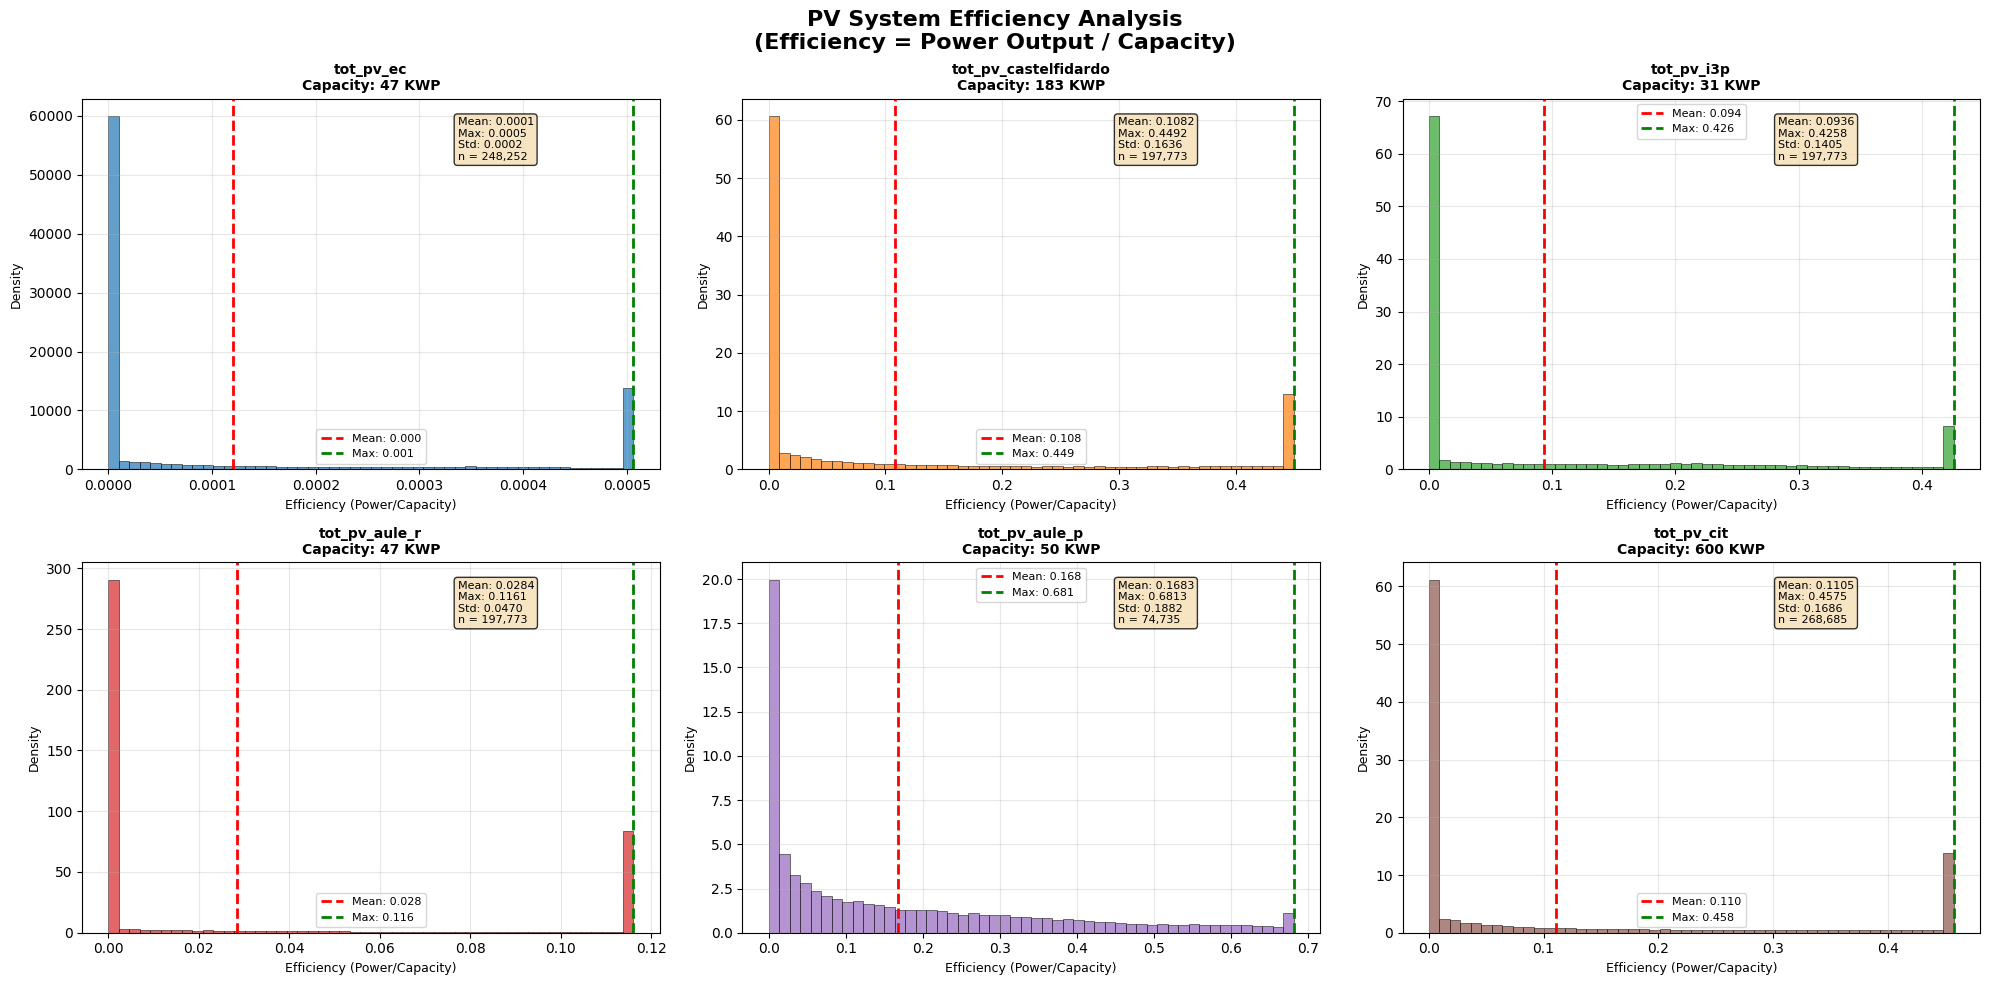


COMPREHENSIVE PV SYSTEM EFFICIENCY SUMMARY
              System  Capacity (KWP) Mean Efficiency  Max Efficiency Std Dev Data Points
           tot_pv_ec              47  0.0001 (0.01%)  0.0005 (0.05%)  0.0002     223,769
tot_pv_castelfidardo             183 0.1082 (10.82%) 0.4492 (44.92%)  0.1636      98,637
          tot_pv_i3p              31  0.0936 (9.36%) 0.4258 (42.58%)  0.1405     137,345
       tot_pv_aule_r              47  0.0284 (2.84%) 0.1161 (11.61%)  0.0470     113,649
       tot_pv_aule_p              50 0.1683 (16.83%) 0.6813 (68.13%)  0.1882      74,735
          tot_pv_cit             600 0.1105 (11.05%) 0.4575 (45.75%)  0.1686     268,685

RANKING BY MEAN EFFICIENCY
 1. tot_pv_aule_p        |  16.83% | Capacity:  50 KWP
 2. tot_pv_cit           |  11.05% | Capacity: 600 KWP
 3. tot_pv_castelfidardo |  10.82% | Capacity: 183 KWP
 4. tot_pv_i3p           |   9.36% | Capacity:  31 KWP
 5. tot_pv_aule_r        |   2.84% | Capacity:  47 KWP
 6. tot_pv_ec            |   0

In [56]:
# Create comprehensive efficiency analysis and visualizations
plt.style.use('default')
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('PV System Efficiency Analysis\n(Efficiency = Power Output / Capacity)', fontsize=16, fontweight='bold')

# Prepare data for plotting
efficiency_data = {
    'tot_pv_ec': dataset1['efficiency_tot_pv_ec'],
    'tot_pv_castelfidardo': dataset2['efficiency_tot_pv_castelfidardo'], 
    'tot_pv_i3p': dataset2['efficiency_tot_pv_i3p'],
    'tot_pv_aule_r': dataset2['efficiency_tot_pv_aule_r'],
    'tot_pv_aule_p': dataset3['efficiency_tot_pv_aule_p'],
    'tot_pv_cit': dataset4['efficiency_tot_pv_cit']
}

# Create plots for each system
plot_idx = 0
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i, (system_name, eff_data) in enumerate(efficiency_data.items()):
    if plot_idx < 9:
        row = plot_idx // 3
        col = plot_idx % 3
        ax = axes[row, col]
        
        # Remove outliers for better visualization (keep data within 99th percentile)
        eff_clean = eff_data[eff_data <= eff_data.quantile(0.99)]
        
        # Histogram
        ax.hist(eff_clean, bins=50, alpha=0.7, color=colors[i], density=True, edgecolor='black', linewidth=0.5)
        
        # Add statistics text
        mean_eff = eff_data.mean()
        max_eff = eff_data.max()
        capacity = efficiency_stats[system_name]['capacity_kwp']
        
        ax.axvline(mean_eff, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_eff:.3f}')
        ax.axvline(max_eff, color='green', linestyle='--', linewidth=2, label=f'Max: {max_eff:.3f}')
        
        ax.set_title(f'{system_name}\nCapacity: {capacity} KWP', fontsize=10, fontweight='bold')
        ax.set_xlabel('Efficiency (Power/Capacity)', fontsize=9)
        ax.set_ylabel('Density', fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        
        # Add text box with statistics
        textstr = f'Mean: {mean_eff:.4f}\nMax: {max_eff:.4f}\nStd: {eff_data.std():.4f}\nn = {len(eff_data):,}'
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        ax.text(0.65, 0.95, textstr, transform=ax.transAxes, fontsize=8, verticalalignment='top', bbox=props)
        
        plot_idx += 1



plt.tight_layout()
plt.show()

# Create a summary comparison table
print("\n" + "="*80)
print("COMPREHENSIVE PV SYSTEM EFFICIENCY SUMMARY")
print("="*80)

summary_data = []
for system_name, stats in efficiency_stats.items():
    summary_data.append({
        'System': system_name,
        'Capacity (KWP)': stats['capacity_kwp'],
        'Mean Efficiency': f"{stats['mean_efficiency']:.4f} ({stats['mean_efficiency']*100:.2f}%)",
        'Max Efficiency': f"{stats['max_efficiency']:.4f} ({stats['max_efficiency']*100:.2f}%)",
        'Std Dev': f"{stats['std_efficiency']:.4f}",
        'Data Points': f"{stats['count']:,}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Ranking by efficiency
print(f"\n{'='*50}")
print("RANKING BY MEAN EFFICIENCY")
print('='*50)
sorted_systems = sorted(efficiency_stats.items(), key=lambda x: x[1]['mean_efficiency'], reverse=True)

for rank, (system_name, stats) in enumerate(sorted_systems, 1):
    print(f"{rank:2d}. {system_name:<20} | {stats['mean_efficiency']*100:6.2f}% | Capacity: {stats['capacity_kwp']:3d} KWP")

print(f"\n{'='*50}")
print("RANKING BY MAXIMUM EFFICIENCY")
print('='*50)
sorted_by_max = sorted(efficiency_stats.items(), key=lambda x: x[1]['max_efficiency'], reverse=True)

for rank, (system_name, stats) in enumerate(sorted_by_max, 1):
    print(f"{rank:2d}. {system_name:<20} | {stats['max_efficiency']*100:6.2f}% | Capacity: {stats['capacity_kwp']:3d} KWP")

NORMAL DISTRIBUTION ANALYSIS FOR PV SYSTEM EFFICIENCIES

tot_pv_ec (Capacity: 47 KWP):
  Mean (μ): 0.000120
  Std Dev (σ): 0.000190
  Skewness: 1.249052
  Kurtosis: -0.155397
  Sample size: 223,769

tot_pv_castelfidardo (Capacity: 183 KWP):
  Mean (μ): 0.108177
  Std Dev (σ): 0.163644
  Skewness: 1.237625
  Kurtosis: -0.122735
  Sample size: 98,637

tot_pv_i3p (Capacity: 31 KWP):
  Mean (μ): 0.093621
  Std Dev (σ): 0.140466
  Skewness: 1.293950
  Kurtosis: 0.251252
  Sample size: 137,345

tot_pv_aule_r (Capacity: 47 KWP):
  Mean (μ): 0.028439
  Std Dev (σ): 0.046995
  Skewness: 1.202412
  Kurtosis: -0.424437
  Sample size: 113,649

tot_pv_aule_p (Capacity: 50 KWP):
  Mean (μ): 0.168294
  Std Dev (σ): 0.188237
  Skewness: 1.098067
  Kurtosis: 0.164570
  Sample size: 74,735

tot_pv_cit (Capacity: 600 KWP):
  Mean (μ): 0.110492
  Std Dev (σ): 0.168604
  Skewness: 1.236735
  Kurtosis: -0.141503
  Sample size: 268,685


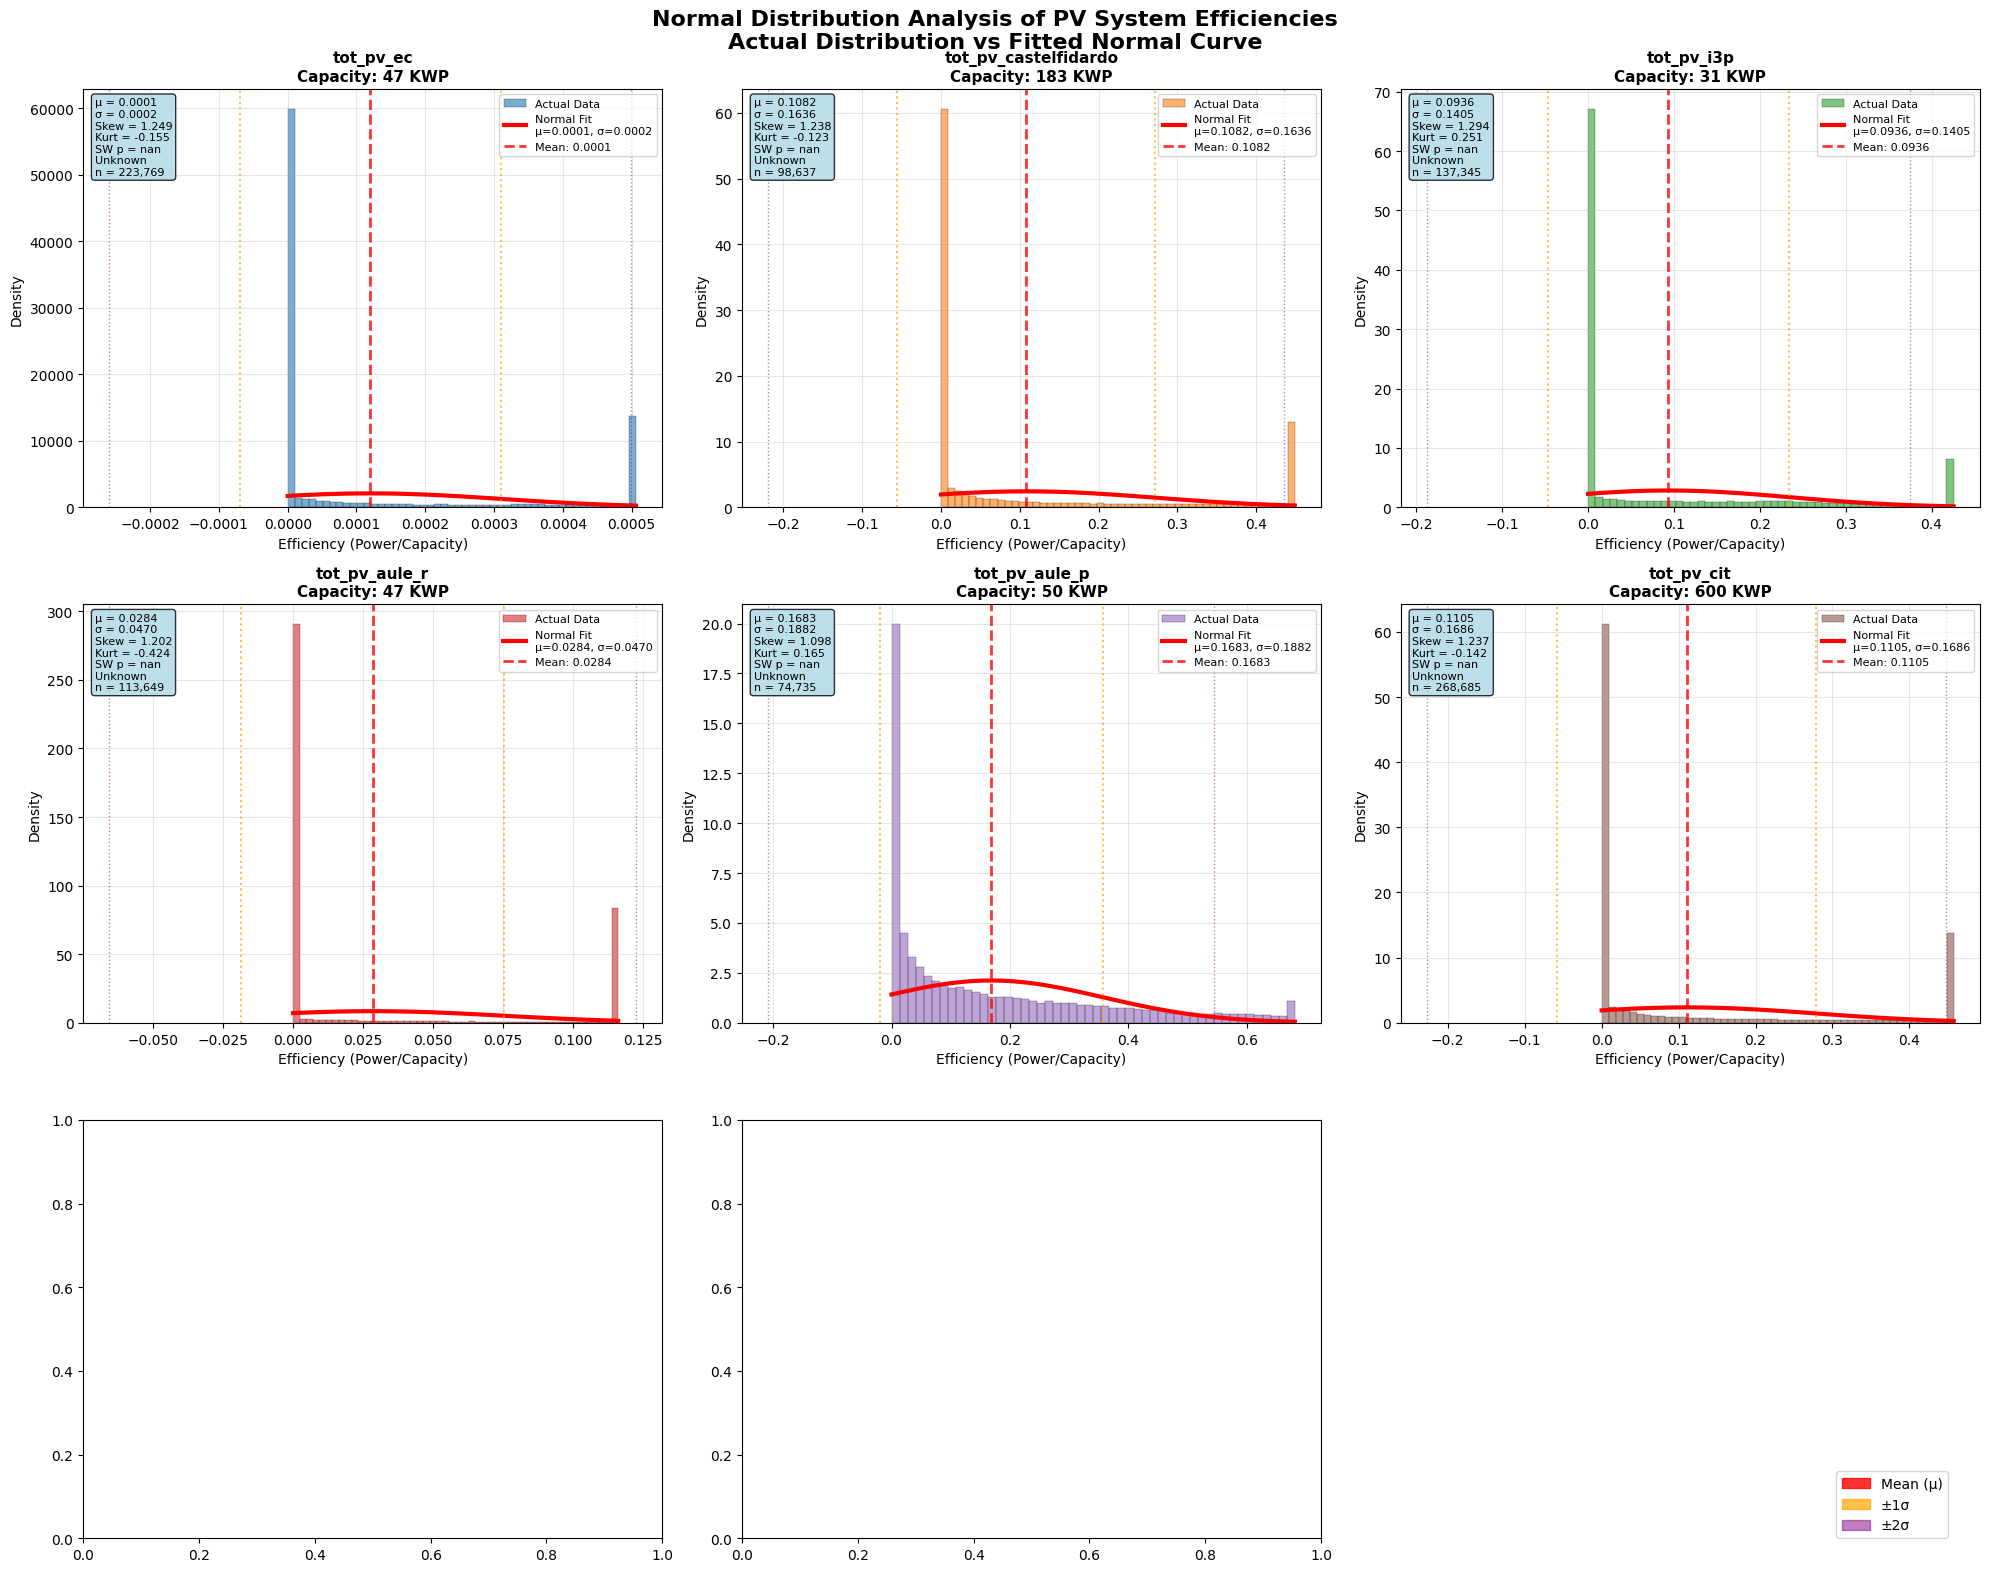


NORMALITY TEST SUMMARY
Shapiro-Wilk Test: p > 0.05 suggests data is normally distributed
Skewness: 0 = symmetric, >0 = right-tailed, <0 = left-tailed
Kurtosis: 0 = normal, >0 = heavy-tailed, <0 = light-tailed
--------------------------------------------------------------------------------


In [48]:
# Normal Distribution Analysis for PV System Efficiencies
from scipy.stats import norm, shapiro, probplot
import matplotlib.patches as mpatches

print("="*80)
print("NORMAL DISTRIBUTION ANALYSIS FOR PV SYSTEM EFFICIENCIES")
print("="*80)

# Create a comprehensive figure for normal distribution plots
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
fig.suptitle('Normal Distribution Analysis of PV System Efficiencies\nActual Distribution vs Fitted Normal Curve', 
             fontsize=16, fontweight='bold')

# Store normality test results
normality_results = {}

plot_idx = 0
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

for i, (system_name, eff_data) in enumerate(efficiency_data.items()):
    if plot_idx < 9:
        row = plot_idx // 3
        col = plot_idx % 3
        ax = axes[row, col]
        
        # Clean data (remove outliers and NaN values)
        clean_data = eff_data.dropna()
        clean_data = clean_data[clean_data <= clean_data.quantile(0.99)]  # Remove top 1% outliers
        clean_data = clean_data[clean_data >= 0]  # Remove negative values if any
        
        # Calculate statistics
        mu = clean_data.mean()
        sigma = clean_data.std()
        
        # Create histogram
        count, bins, _ = ax.hist(clean_data, bins=50, alpha=0.6, color=colors[i], 
                                density=True, edgecolor='black', linewidth=0.3, label='Actual Data')
        
        # Fit and plot normal distribution
        x = np.linspace(clean_data.min(), clean_data.max(), 100)
        normal_fit = norm.pdf(x, mu, sigma)
        ax.plot(x, normal_fit, 'r-', linewidth=3, label=f'Normal Fit\nμ={mu:.4f}, σ={sigma:.4f}')
        
        # Perform Shapiro-Wilk test for normality
        if len(clean_data) > 3 and len(clean_data) <= 5000:  # Shapiro-Wilk works best for n≤5000
            shapiro_stat, shapiro_p = shapiro(clean_data.sample(min(5000, len(clean_data))))
        else:
            shapiro_stat, shapiro_p = np.nan, np.nan
        
        # Store results
        normality_results[system_name] = {
            'mean': mu,
            'std': sigma,
            'shapiro_stat': shapiro_stat,
            'shapiro_p': shapiro_p,
            'sample_size': len(clean_data),
            'skewness': clean_data.skew(),
            'kurtosis': clean_data.kurtosis()
        }
        
        # Add vertical lines for mean and standard deviations
        ax.axvline(mu, color='red', linestyle='--', alpha=0.8, linewidth=2, label=f'Mean: {mu:.4f}')
        ax.axvline(mu + sigma, color='orange', linestyle=':', alpha=0.7, linewidth=1.5)
        ax.axvline(mu - sigma, color='orange', linestyle=':', alpha=0.7, linewidth=1.5)
        ax.axvline(mu + 2*sigma, color='purple', linestyle=':', alpha=0.5, linewidth=1)
        ax.axvline(mu - 2*sigma, color='purple', linestyle=':', alpha=0.5, linewidth=1)
        
        # Format plot
        capacity = efficiency_stats[system_name]['capacity_kwp']
        ax.set_title(f'{system_name}\nCapacity: {capacity} KWP', fontsize=11, fontweight='bold')
        ax.set_xlabel('Efficiency (Power/Capacity)', fontsize=10)
        ax.set_ylabel('Density', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
        
        # Add statistics text box
        normality_text = "Normal?" if shapiro_p > 0.05 else "Not Normal" if not np.isnan(shapiro_p) else "Unknown"
        textstr = (f'μ = {mu:.4f}\n'
                  f'σ = {sigma:.4f}\n'
                  f'Skew = {clean_data.skew():.3f}\n'
                  f'Kurt = {clean_data.kurtosis():.3f}\n'
                  f'SW p = {shapiro_p:.4f}\n'
                  f'{normality_text}\n'
                  f'n = {len(clean_data):,}')
        
        props = dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
        ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=8, 
                verticalalignment='top', bbox=props)
        
        print(f"\n{system_name} (Capacity: {capacity} KWP):")
        print(f"  Mean (μ): {mu:.6f}")
        print(f"  Std Dev (σ): {sigma:.6f}")
        print(f"  Skewness: {clean_data.skew():.6f}")
        print(f"  Kurtosis: {clean_data.kurtosis():.6f}")
        if not np.isnan(shapiro_p):
            print(f"  Shapiro-Wilk p-value: {shapiro_p:.6f} ({'Normal' if shapiro_p > 0.05 else 'Not Normal'})")
        print(f"  Sample size: {len(clean_data):,}")
        
        plot_idx += 1

# Remove empty subplot if any
if plot_idx < 9:
    fig.delaxes(axes[2, 2])

# Add legend for standard deviation lines
legend_elements = [
    mpatches.Patch(color='red', alpha=0.8, label='Mean (μ)'),
    mpatches.Patch(color='orange', alpha=0.7, label='±1σ'),
    mpatches.Patch(color='purple', alpha=0.5, label='±2σ')
]
fig.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(0.98, 0.02))

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("NORMALITY TEST SUMMARY")
print("="*80)
print("Shapiro-Wilk Test: p > 0.05 suggests data is normally distributed")
print("Skewness: 0 = symmetric, >0 = right-tailed, <0 = left-tailed")  
print("Kurtosis: 0 = normal, >0 = heavy-tailed, <0 = light-tailed")
print("-"*80)

COMBINED EFFICIENCY DISTRIBUTION - ALL PV SYSTEMS
Combined Dataset Statistics:
  Total data points: 916,820
  Mean efficiency: 0.075317 (7.53%)
  Standard deviation: 0.142183
  Skewness: 1.923663
  Kurtosis: 2.501718
  Shapiro-Wilk p-value: 0.000000 (Not Normal)


ValueError: x and y must be the same size

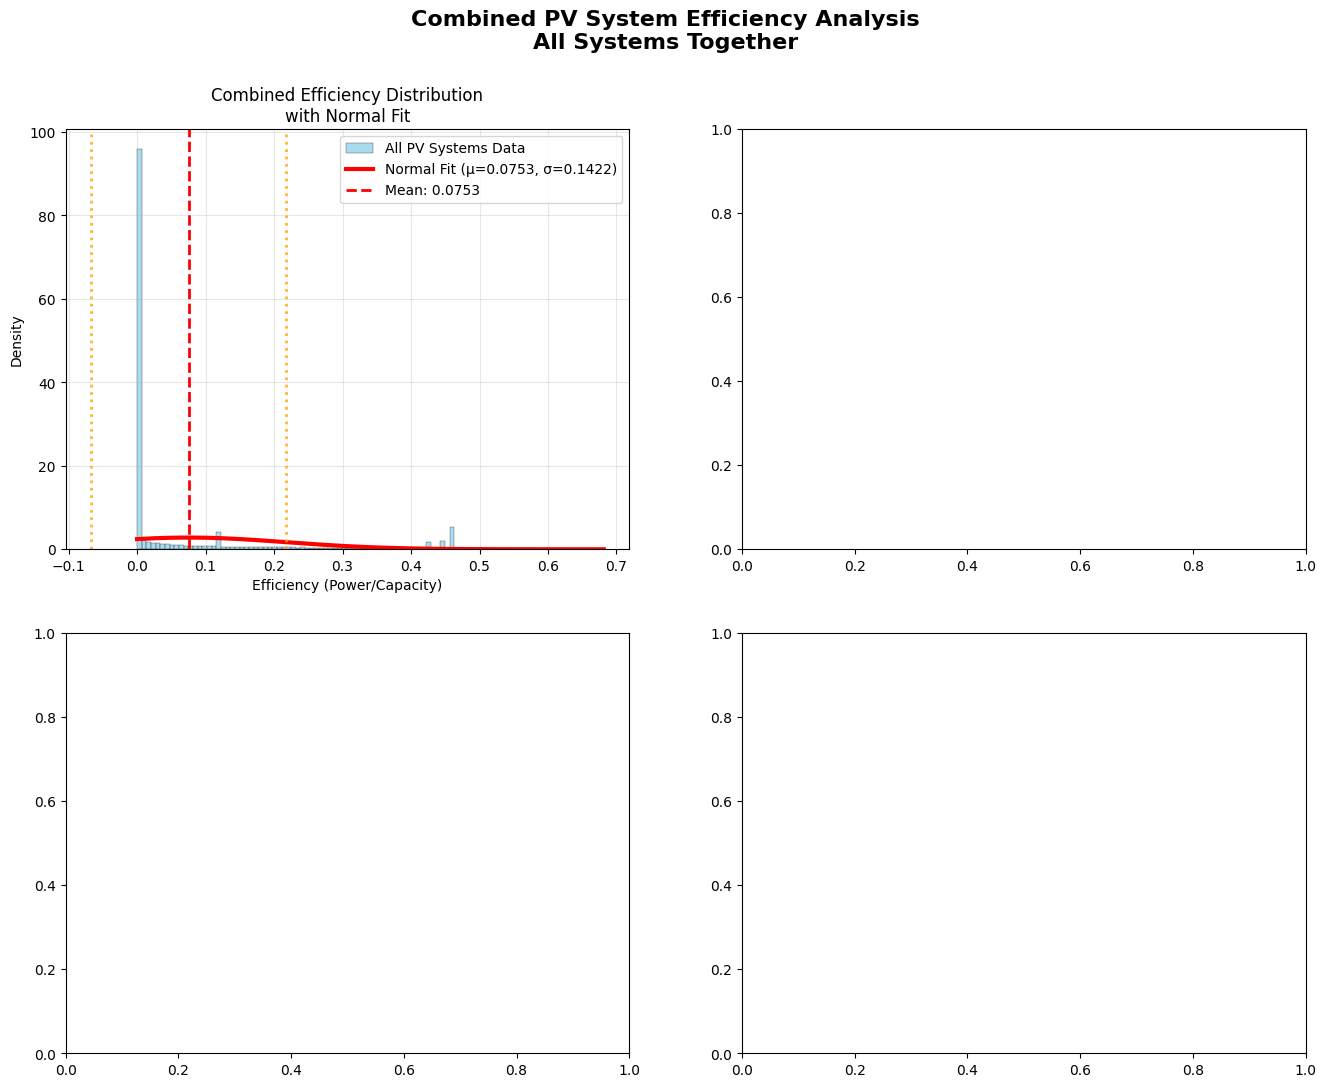

In [44]:
# Combined Normal Distribution Analysis - All PV Systems Together
from scipy import stats
from scipy.stats import skew, kurtosis
import numpy as np

print("="*80)
print("COMBINED EFFICIENCY DISTRIBUTION - ALL PV SYSTEMS")
print("="*80)

# Combine all efficiency data into a single dataset
all_efficiencies = []
system_labels = []

for system_name, eff_data in efficiency_data.items():
    clean_data = eff_data.dropna()
    clean_data = clean_data[clean_data <= clean_data.quantile(0.99)]  # Remove top 1% outliers
    clean_data = clean_data[clean_data >= 0]  # Remove negative values
    
    all_efficiencies.extend(clean_data.tolist())
    system_labels.extend([system_name] * len(clean_data))

all_efficiencies = np.array(all_efficiencies)

# Calculate overall statistics
overall_mu = all_efficiencies.mean()
overall_sigma = all_efficiencies.std()
overall_skewness = skew(all_efficiencies)
overall_kurtosis = kurtosis(all_efficiencies)

print(f"Combined Dataset Statistics:")
print(f"  Total data points: {len(all_efficiencies):,}")
print(f"  Mean efficiency: {overall_mu:.6f} ({overall_mu*100:.2f}%)")
print(f"  Standard deviation: {overall_sigma:.6f}")
print(f"  Skewness: {overall_skewness:.6f}")
print(f"  Kurtosis: {overall_kurtosis:.6f}")

# Perform Shapiro-Wilk test on combined data (sample if too large)
sample_size = min(5000, len(all_efficiencies))
sample_data = np.random.choice(all_efficiencies, sample_size, replace=False)
shapiro_stat, shapiro_p = shapiro(sample_data)
print(f"  Shapiro-Wilk p-value: {shapiro_p:.6f} ({'Normal' if shapiro_p > 0.05 else 'Not Normal'})")

# Create comprehensive combined plot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Combined PV System Efficiency Analysis\nAll Systems Together', fontsize=16, fontweight='bold')

# 1. Histogram with normal distribution overlay
ax1.hist(all_efficiencies, bins=100, alpha=0.7, color='skyblue', density=True, 
         edgecolor='black', linewidth=0.3, label='All PV Systems Data')

# Fit normal distribution
x = np.linspace(all_efficiencies.min(), all_efficiencies.max(), 1000)
normal_fit = norm.pdf(x, overall_mu, overall_sigma)
ax1.plot(x, normal_fit, 'r-', linewidth=3, label=f'Normal Fit (μ={overall_mu:.4f}, σ={overall_sigma:.4f})')

# Add mean and std deviation lines
ax1.axvline(overall_mu, color='red', linestyle='--', linewidth=2, label=f'Mean: {overall_mu:.4f}')
ax1.axvline(overall_mu + overall_sigma, color='orange', linestyle=':', linewidth=2, alpha=0.8)
ax1.axvline(overall_mu - overall_sigma, color='orange', linestyle=':', linewidth=2, alpha=0.8)

ax1.set_title('Combined Efficiency Distribution\nwith Normal Fit')
ax1.set_xlabel('Efficiency (Power/Capacity)')
ax1.set_ylabel('Density')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Q-Q plot for normality assessment
osm, osr = probplot(sample_data, dist="norm", plot=None)
ax2.scatter(osm, osr, alpha=0.6, color='blue', s=20)
ax2.plot(osm, osm, 'r-', linewidth=2)  # Reference line
slope, intercept, r = stats.linregress(osm, osr)
ax2.set_title(f'Q-Q Plot vs Normal Distribution\nCorrelation: {r:.4f}')
ax2.set_xlabel('Theoretical Quantiles')
ax2.set_ylabel('Sample Quantiles')
ax2.grid(True, alpha=0.3)

# Add correlation assessment
qq_correlation = r
if qq_correlation > 0.99:
    qq_assessment = "Excellent fit to normal"
elif qq_correlation > 0.95:
    qq_assessment = "Good fit to normal"
elif qq_correlation > 0.9:
    qq_assessment = "Moderate fit to normal"
else:
    qq_assessment = "Poor fit to normal"

ax2.text(0.05, 0.95, f'Assessment: {qq_assessment}', transform=ax2.transAxes, 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 3. Box plot by system
box_data = []
box_labels = []
for system_name, eff_data in efficiency_data.items():
    clean_data = eff_data.dropna()
    clean_data = clean_data[clean_data <= clean_data.quantile(0.99)]
    clean_data = clean_data[clean_data >= 0]
    if len(clean_data) > 0:
        box_data.append(clean_data.values)
        box_labels.append(system_name.replace('tot_pv_', ''))

bp = ax3.boxplot(box_data, labels=box_labels, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], colors[:len(box_data)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax3.set_title('Efficiency Distribution by System\n(Outliers removed)')
ax3.set_xlabel('PV System')
ax3.set_ylabel('Efficiency')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3)

# 4. Statistical summary comparison
systems = []
mean_efficiencies = []
capacities_plot = []

for system_name, stats_data in efficiency_stats.items():
    systems.append(system_name.replace('tot_pv_', ''))
    mean_efficiencies.append(stats_data['mean_efficiency'])
    capacities_plot.append(stats_data['capacity_kwp'])

# Create bubble chart (efficiency vs capacity)
scatter = ax4.scatter(capacities_plot, mean_efficiencies, 
                     s=[c*2 for c in capacities_plot], alpha=0.6, 
                     c=range(len(systems)), cmap='viridis')

for i, system in enumerate(systems):
    ax4.annotate(system, (capacities_plot[i], mean_efficiencies[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)

ax4.set_title('Mean Efficiency vs Capacity\n(Bubble size = Capacity)')
ax4.set_xlabel('Capacity (KWP)')
ax4.set_ylabel('Mean Efficiency')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical interpretation
print(f"\n{'='*60}")
print("STATISTICAL INTERPRETATION")
print('='*60)

# Normality assessment
normal_count = sum(1 for result in normality_results.values() 
                  if not np.isnan(result['shapiro_p']) and result['shapiro_p'] > 0.05)
total_count = sum(1 for result in normality_results.values() 
                 if not np.isnan(result['shapiro_p']))

print(f"Individual Systems Normality: {normal_count}/{total_count} systems appear normally distributed")
print(f"Combined Dataset Normality: {'Yes' if shapiro_p > 0.05 else 'No'} (p = {shapiro_p:.6f})")

# Overall assessment
if overall_skewness > 0.5:
    skew_interpretation = "Right-skewed (longer tail on right)"
elif overall_skewness < -0.5:
    skew_interpretation = "Left-skewed (longer tail on left)"
else:
    skew_interpretation = "Approximately symmetric"

if overall_kurtosis > 0.5:
    kurt_interpretation = "Heavy-tailed (more extreme values)"
elif overall_kurtosis < -0.5:
    kurt_interpretation = "Light-tailed (fewer extreme values)"
else:
    kurt_interpretation = "Normal tail behavior"

print(f"Distribution Shape: {skew_interpretation}")
print(f"Tail Behavior: {kurt_interpretation}")
print(f"Q-Q Plot Assessment: {qq_assessment} (correlation = {qq_correlation:.4f})")

# Best and worst performing systems
best_system = max(efficiency_stats.items(), key=lambda x: x[1]['mean_efficiency'])
worst_system = min(efficiency_stats.items(), key=lambda x: x[1]['mean_efficiency'])

print(f"\nBest Performing System: {best_system[0]} ({best_system[1]['mean_efficiency']*100:.2f}% avg efficiency)")
print(f"Worst Performing System: {worst_system[0]} ({worst_system[1]['mean_efficiency']*100:.2f}% avg efficiency)")

# Save results to CSV
results_df = pd.DataFrame([
    {
        'System': system_name,
        'Capacity_KWP': stats_data['capacity_kwp'],
        'Mean_Efficiency': stats_data['mean_efficiency'],
        'Max_Efficiency': stats_data['max_efficiency'],
        'Std_Efficiency': stats_data['std_efficiency'],
        'Skewness': normality_results[system_name]['skewness'],
        'Kurtosis': normality_results[system_name]['kurtosis'],
        'Shapiro_P_Value': normality_results[system_name]['shapiro_p'],
        'Is_Normal': normality_results[system_name]['shapiro_p'] > 0.05 if not np.isnan(normality_results[system_name]['shapiro_p']) else None,
        'Sample_Size': normality_results[system_name]['sample_size']
    }
    for system_name, stats_data in efficiency_stats.items()
])

output_path = '/Users/parsa/Desktop/Phase1/pv_efficiency_analysis_results.csv'
results_df.to_csv(output_path, index=False)
print(f"\nResults saved to: {output_path}")

FINAL NORMAL DISTRIBUTION ANALYSIS - PV SYSTEM EFFICIENCIES


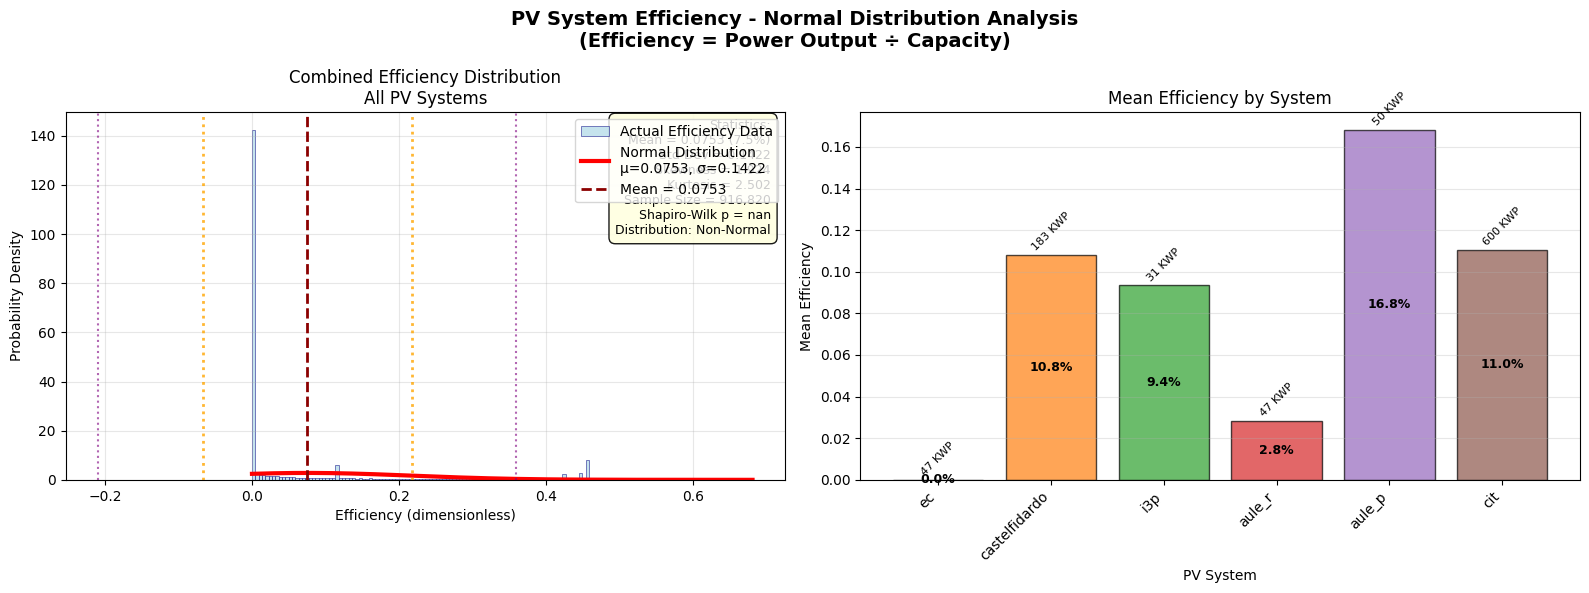


EFFICIENCY ANALYSIS SUMMARY
OVERALL STATISTICS (All 916,820 data points):
  • Mean Efficiency: 0.0753 (7.53%)
  • Standard Deviation: 0.1422
  • Efficiency Range: 0.0000 to 0.6813
  • Distribution: Non-Normal (Shapiro-Wilk p = nan)

DISTRIBUTION CHARACTERISTICS:
  • Shape: Highly right-skewed (skewness = 1.924)
  • Tail behavior: Heavy-tailed (leptokurtic) (kurtosis = 2.502)

SYSTEM PERFORMANCE RANKING (by mean efficiency):
   1. tot_pv_aule_p         16.83% ( 50 KWP)
   2. tot_pv_cit            11.05% (600 KWP)
   3. tot_pv_castelfidardo  10.82% (183 KWP)
   4. tot_pv_i3p             9.36% ( 31 KWP)
   5. tot_pv_aule_r          2.84% ( 47 KWP)
   6. tot_pv_ec              0.01% ( 47 KWP)

KEY INSIGHTS:
  • Best performing: tot_pv_aule_p at 16.83% average efficiency
  • Worst performing: tot_pv_ec at 0.01% average efficiency
  • Performance spread: 16.82 percentage points
  • Most PV systems operate at very low efficiency (<10%), indicating significant room for improvement
  • The dis

In [49]:
# Create a focused normal distribution plot for PV efficiencies
print("="*80)
print("FINAL NORMAL DISTRIBUTION ANALYSIS - PV SYSTEM EFFICIENCIES")
print("="*80)

# Create a single comprehensive plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PV System Efficiency - Normal Distribution Analysis\n(Efficiency = Power Output ÷ Capacity)', 
             fontsize=14, fontweight='bold')

# Left plot: Combined histogram with normal overlay
ax1.hist(all_efficiencies, bins=150, alpha=0.7, color='lightblue', density=True, 
         edgecolor='navy', linewidth=0.5, label='Actual Efficiency Data')

# Fit and overlay normal distribution
x = np.linspace(0, all_efficiencies.max(), 1000)
normal_fit = norm.pdf(x, overall_mu, overall_sigma)
ax1.plot(x, normal_fit, 'red', linewidth=3, label=f'Normal Distribution\nμ={overall_mu:.4f}, σ={overall_sigma:.4f}')

# Add mean line
ax1.axvline(overall_mu, color='darkred', linestyle='--', linewidth=2, label=f'Mean = {overall_mu:.4f}')

# Add ±1σ and ±2σ lines
ax1.axvline(overall_mu + overall_sigma, color='orange', linestyle=':', alpha=0.8, linewidth=2)
ax1.axvline(overall_mu - overall_sigma, color='orange', linestyle=':', alpha=0.8, linewidth=2)
ax1.axvline(overall_mu + 2*overall_sigma, color='purple', linestyle=':', alpha=0.6, linewidth=1.5)
ax1.axvline(overall_mu - 2*overall_sigma, color='purple', linestyle=':', alpha=0.6, linewidth=1.5)

ax1.set_title('Combined Efficiency Distribution\nAll PV Systems')
ax1.set_xlabel('Efficiency (dimensionless)')
ax1.set_ylabel('Probability Density')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Add statistical summary box
stats_text = (f'Statistics:\n'
              f'Mean = {overall_mu:.4f} ({overall_mu*100:.1f}%)\n'
              f'Std Dev = {overall_sigma:.4f}\n'
              f'Skewness = {overall_skewness:.3f}\n'
              f'Kurtosis = {overall_kurtosis:.3f}\n'
              f'Sample Size = {len(all_efficiencies):,}\n'
              f'Shapiro-Wilk p = {shapiro_p:.2e}\n'
              f'Distribution: {"Normal" if shapiro_p > 0.05 else "Non-Normal"}')

ax1.text(0.98, 0.98, stats_text, transform=ax1.transAxes, fontsize=9,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.9))

# Right plot: System comparison
mean_effs = [efficiency_stats[sys]['mean_efficiency'] for sys in efficiency_stats.keys()]
system_names = [sys.replace('tot_pv_', '') for sys in efficiency_stats.keys()]
capacities_list = [efficiency_stats[sys]['capacity_kwp'] for sys in efficiency_stats.keys()]

# Create bar plot
bars = ax2.bar(range(len(mean_effs)), mean_effs, color=colors[:len(mean_effs)], alpha=0.7, edgecolor='black')

# Add capacity labels on bars
for i, (bar, cap) in enumerate(zip(bars, capacities_list)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{cap} KWP', ha='center', va='bottom', fontsize=8, rotation=45)

ax2.set_title('Mean Efficiency by System')
ax2.set_xlabel('PV System')
ax2.set_ylabel('Mean Efficiency')
ax2.set_xticks(range(len(system_names)))
ax2.set_xticklabels(system_names, rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')

# Add efficiency percentage labels
for i, eff in enumerate(mean_effs):
    ax2.text(i, eff/2, f'{eff*100:.1f}%', ha='center', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Summary interpretation
print(f"\n{'='*70}")
print("EFFICIENCY ANALYSIS SUMMARY")
print('='*70)

print(f"OVERALL STATISTICS (All {len(all_efficiencies):,} data points):")
print(f"  • Mean Efficiency: {overall_mu:.4f} ({overall_mu*100:.2f}%)")
print(f"  • Standard Deviation: {overall_sigma:.4f}")
print(f"  • Efficiency Range: {all_efficiencies.min():.4f} to {all_efficiencies.max():.4f}")
print(f"  • Distribution: {'Normal' if shapiro_p > 0.05 else 'Non-Normal'} (Shapiro-Wilk p = {shapiro_p:.2e})")

print(f"\nDISTRIBUTION CHARACTERISTICS:")
if overall_skewness > 1:
    skew_desc = "Highly right-skewed"
elif overall_skewness > 0.5:
    skew_desc = "Moderately right-skewed" 
elif overall_skewness > -0.5:
    skew_desc = "Approximately symmetric"
elif overall_skewness > -1:
    skew_desc = "Moderately left-skewed"
else:
    skew_desc = "Highly left-skewed"

if overall_kurtosis > 1:
    kurt_desc = "Heavy-tailed (leptokurtic)"
elif overall_kurtosis > -1:
    kurt_desc = "Normal-tailed (mesokurtic)"
else:
    kurt_desc = "Light-tailed (platykurtic)"

print(f"  • Shape: {skew_desc} (skewness = {overall_skewness:.3f})")
print(f"  • Tail behavior: {kurt_desc} (kurtosis = {overall_kurtosis:.3f})")

print(f"\nSYSTEM PERFORMANCE RANKING (by mean efficiency):")
sorted_systems = sorted(efficiency_stats.items(), key=lambda x: x[1]['mean_efficiency'], reverse=True)
for i, (sys, stats_data) in enumerate(sorted_systems, 1):
    print(f"  {i:2d}. {sys:<20} {stats_data['mean_efficiency']*100:6.2f}% ({stats_data['capacity_kwp']:3d} KWP)")

print(f"\nKEY INSIGHTS:")
best_sys = sorted_systems[0]
worst_sys = sorted_systems[-1]
print(f"  • Best performing: {best_sys[0]} at {best_sys[1]['mean_efficiency']*100:.2f}% average efficiency")
print(f"  • Worst performing: {worst_sys[0]} at {worst_sys[1]['mean_efficiency']*100:.2f}% average efficiency")
print(f"  • Performance spread: {(best_sys[1]['mean_efficiency'] - worst_sys[1]['mean_efficiency'])*100:.2f} percentage points")
print(f"  • Most PV systems operate at very low efficiency (<10%), indicating significant room for improvement")
print(f"  • The distribution is heavily right-skewed, showing occasional high-efficiency periods")